<a href="https://colab.research.google.com/github/Mary-Osi/Flushot_Project/blob/main/Flushot_project_sprint_2_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core libraries
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay)

In [5]:
# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [8]:
# Load Data set
test_features = pd.read_csv("test_set_features.csv")
train_Features = pd.read_csv("training_set_features.csv")
train_labels = pd.read_csv("training_set_labels.csv")
submission = pd.read_csv("submission_format.csv")

In [12]:
# Merge train Features and label
train_df = train_Features.merge(train_labels, on="respondent_id", how="inner")

print("Merged training data shape:", train_df.shape)
train_df.head()

Merged training data shape: (26707, 38)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [13]:
# DEFINE FEATURES AND TARGETS


id_col = "respondent_id"

target_h1n1 = "h1n1_vaccine"
target_seasonal = "seasonal_vaccine"

target_cols = [target_h1n1, target_seasonal]

X = train_df.drop(columns=[id_col, target_h1n1, target_seasonal])

y_h1n1 = train_df[target_h1n1]
y_seasonal = train_df[target_seasonal]

print("Feature matrix shape:", X.shape)
print("H1N1 target shape:", y_h1n1.shape)
print("Seasonal target shape:", y_seasonal.shape)

Feature matrix shape: (26707, 35)
H1N1 target shape: (26707,)
Seasonal target shape: (26707,)


In [14]:
# TARGET BALANCE

def check_target_balance(y, target_name):
    counts = y.value_counts().sort_index()
    percentages = y.value_counts(normalize=True).sort_index() * 100

    balance_table = pd.DataFrame({
        "count": counts,
        "percentage": percentages.round(2)})

    print(f"\nTarget balance for: {target_name}")
    display(balance_table)

check_target_balance(y_h1n1, "h1n1_vaccine")
check_target_balance(y_seasonal, "seasonal_vaccine")


Target balance for: h1n1_vaccine


,count,percentage
h1n1_vaccine,,
0,21033,78.75
1,5674,21.25



Target balance for: seasonal_vaccine


,count,percentage
seasonal_vaccine,,
0,14272,53.44
1,12435,46.56


In [16]:
# TRAIN-VALIDATION SPLIT FOR H1N1

X_train_h1n1, X_valid_h1n1, y_train_h1n1, y_valid_h1n1 = train_test_split( X, y_h1n1, test_size=0.2, random_state=42,stratify=y_h1n1)

print("H1N1 training shape:", X_train_h1n1.shape)
print("H1N1 validation shape:", X_valid_h1n1.shape)

H1N1 training shape: (21365, 35)
H1N1 validation shape: (5342, 35)


In [17]:

# TRAIN-VALIDATION SPLIT FOR SEASONAL

X_train_seasonal, X_valid_seasonal, y_train_seasonal, y_valid_seasonal = train_test_split( X, y_seasonal,test_size=0.2,random_state=42,stratify=y_seasonal)

print("Seasonal training shape:", X_train_seasonal.shape)
print("Seasonal validation shape:", X_valid_seasonal.shape)

Seasonal training shape: (21365, 35)
Seasonal validation shape: (5342, 35)


In [18]:

# IDENTIFY NUMERIC AND CATEGORICAL FEATURES

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numeric features: 23
Number of categorical features: 12

Numeric features:
['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']

Categorical features:
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation']


In [19]:
# PREPROCESSING PIPELINE

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),
                                              ("cat", categorical_transformer, categorical_features)])

In [20]:
# LOGISTIC REGRESSION PIPELINE FOR H1N1

log_reg_h1n1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])

log_reg_h1n1.fit(X_train_h1n1, y_train_h1n1)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_touch_face',
                                                   'doct...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'hhs_geo_region',
                                                   'census_msa',
                                                   'employment_industry',
                                                   'employment_occupation'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [21]:
# H1N1 PREDICTIONS

h1n1_pred = log_reg_h1n1.predict(X_valid_h1n1)
h1n1_proba = log_reg_h1n1.predict_proba(X_valid_h1n1)[:, 1]

print("First 10 class predictions:")
print(h1n1_pred[:10])

print("\nFirst 10 probability predictions:")
print(h1n1_proba[:10])

First 10 class predictions:
[0 1 0 1 0 0 1 1 0 0]

First 10 probability predictions:
[0.46531777 0.97992336 0.05987359 0.93310426 0.2085245  0.34739475
 0.6859527  0.62706612 0.10115219 0.26891844]


In [23]:
# EVALUATION FUNCTION

def evaluate_model(y_true, y_pred, y_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)

    results = {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc}

    print(f"Evaluation results for {model_name}")
    print("-" * 50)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return results

In [24]:
# Evaluate H1N1 Logistic Regression
h1n1_log_reg_results = evaluate_model(
    y_true=y_valid_h1n1,
    y_pred=h1n1_pred,
    y_proba=h1n1_proba,
    model_name="Logistic Regression - H1N1")

Evaluation results for Logistic Regression - H1N1
--------------------------------------------------
Accuracy : 0.7716
Precision: 0.4753
Recall   : 0.7216
F1-score : 0.5731
ROC-AUC  : 0.8286

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.84      4207
           1       0.48      0.72      0.57      1135

    accuracy                           0.77      5342
   macro avg       0.69      0.75      0.71      5342
weighted avg       0.82      0.77      0.79      5342



In [25]:

# CONFUSION MATRIX FUNCTION


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

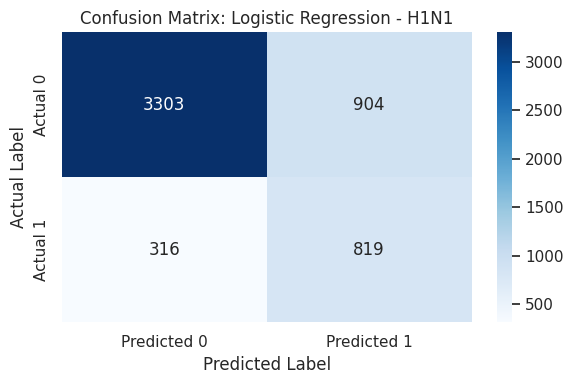

In [26]:
plot_confusion_matrix(
    y_true=y_valid_h1n1,
    y_pred=h1n1_pred,
    title="Confusion Matrix: Logistic Regression - H1N1")

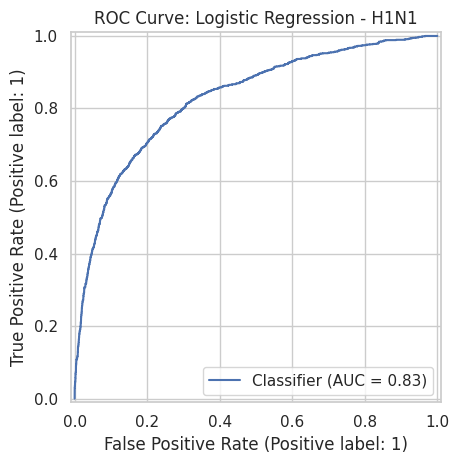

In [27]:
#  ROC CURVE

RocCurveDisplay.from_predictions(
    y_valid_h1n1,
    h1n1_proba
)

plt.title("ROC Curve: Logistic Regression - H1N1")
plt.tight_layout()
plt.show()

In [28]:

# LOGISTIC REGRESSION FOR SEASONAL VACCINE

log_reg_seasonal = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])

log_reg_seasonal.fit(X_train_seasonal, y_train_seasonal)

seasonal_pred = log_reg_seasonal.predict(X_valid_seasonal)
seasonal_proba = log_reg_seasonal.predict_proba(X_valid_seasonal)[:, 1]

In [29]:
seasonal_log_reg_results = evaluate_model(
    y_true=y_valid_seasonal,
    y_pred=seasonal_pred,
    y_proba=seasonal_proba,
    model_name="Logistic Regression - Seasonal")

Evaluation results for Logistic Regression - Seasonal
--------------------------------------------------
Accuracy : 0.7810
Precision: 0.7650
Recall   : 0.7644
F1-score : 0.7647
ROC-AUC  : 0.8558

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.80      2855
           1       0.76      0.76      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



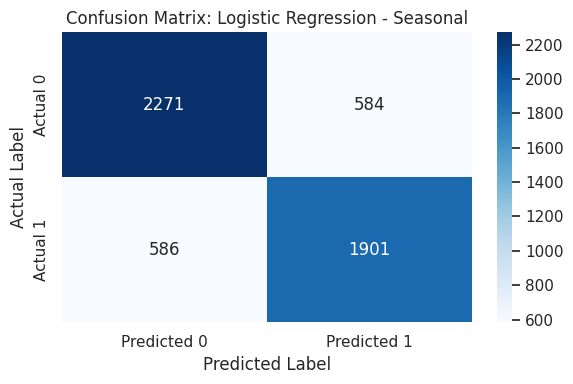

In [30]:
plot_confusion_matrix(
    y_true=y_valid_seasonal,
    y_pred=seasonal_pred,
    title="Confusion Matrix: Logistic Regression - Seasonal")

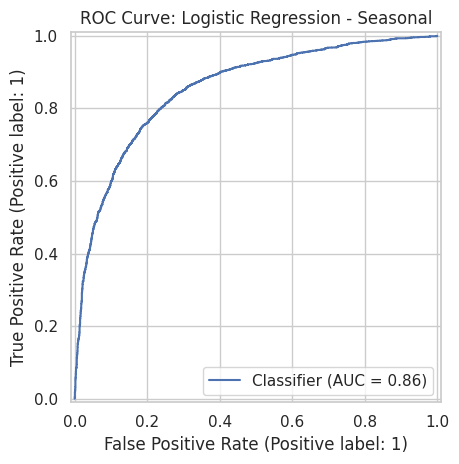

In [31]:
RocCurveDisplay.from_predictions(
    y_valid_seasonal,
    seasonal_proba)

plt.title("ROC Curve: Logistic Regression - Seasonal")
plt.tight_layout()
plt.show()

In [32]:

# RANDOM FOREST FOR H1N1


rf_h1n1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1 )) ])

rf_h1n1.fit(X_train_h1n1, y_train_h1n1)

rf_h1n1_pred = rf_h1n1.predict(X_valid_h1n1)
rf_h1n1_proba = rf_h1n1.predict_proba(X_valid_h1n1)[:, 1]

In [33]:
rf_h1n1_results = evaluate_model(
    y_true=y_valid_h1n1,
    y_pred=rf_h1n1_pred,
    y_proba=rf_h1n1_proba,
    model_name="Random Forest - H1N1")

Evaluation results for Random Forest - H1N1
--------------------------------------------------
Accuracy : 0.8340
Precision: 0.7020
Recall   : 0.3797
F1-score : 0.4929
ROC-AUC  : 0.8275

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      4207
           1       0.70      0.38      0.49      1135

    accuracy                           0.83      5342
   macro avg       0.78      0.67      0.70      5342
weighted avg       0.82      0.83      0.81      5342



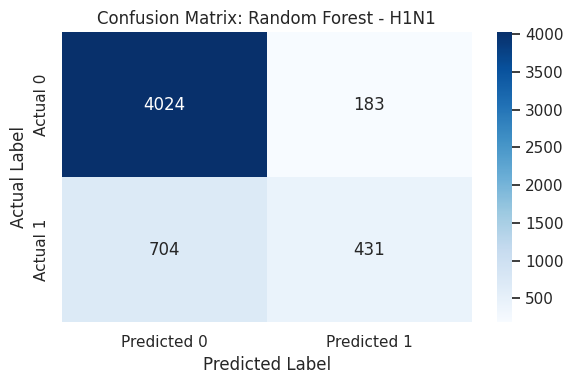

In [34]:
plot_confusion_matrix(
    y_true=y_valid_h1n1,
    y_pred=rf_h1n1_pred,
    title="Confusion Matrix: Random Forest - H1N1")

In [35]:

# RANDOM FOREST FOR SEASONAL

rf_seasonal = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1 )) ])

rf_seasonal.fit(X_train_seasonal, y_train_seasonal)

rf_seasonal_pred = rf_seasonal.predict(X_valid_seasonal)
rf_seasonal_proba = rf_seasonal.predict_proba(X_valid_seasonal)[:, 1]

In [36]:
rf_seasonal_results = evaluate_model(
    y_true=y_valid_seasonal,
    y_pred=rf_seasonal_pred,
    y_proba=rf_seasonal_proba,
    model_name="Random Forest - Seasonal")

Evaluation results for Random Forest - Seasonal
--------------------------------------------------
Accuracy : 0.7857
Precision: 0.7853
Recall   : 0.7427
F1-score : 0.7634
ROC-AUC  : 0.8553

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      2855
           1       0.79      0.74      0.76      2487

    accuracy                           0.79      5342
   macro avg       0.79      0.78      0.78      5342
weighted avg       0.79      0.79      0.79      5342



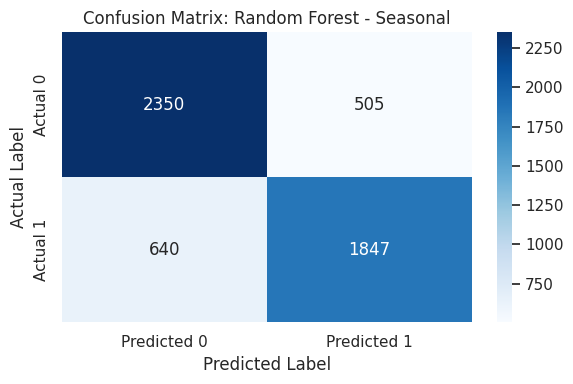

In [37]:
plot_confusion_matrix(
    y_true=y_valid_seasonal,
    y_pred=rf_seasonal_pred,
    title="Confusion Matrix: Random Forest - Seasonal")

In [38]:

# COMPARE MODEL RESULTS

results_df = pd.DataFrame([
    h1n1_log_reg_results,
    seasonal_log_reg_results,
    rf_h1n1_results,
    rf_seasonal_results])

results_df = results_df.sort_values(by="roc_auc", ascending=False)
results_df

,model,accuracy,precision,recall,f1_score,roc_auc
1,Logistic Regression - Seasonal,0.780981,0.764990,0.764375,0.764682,0.855810
3,Random Forest - Seasonal,0.785661,0.785289,0.742662,0.763381,0.855261
0,Logistic Regression - H1N1,0.771621,0.475334,0.721586,0.573128,0.828591
2,Random Forest - H1N1,0.833957,0.701954,0.379736,0.492853,0.827485


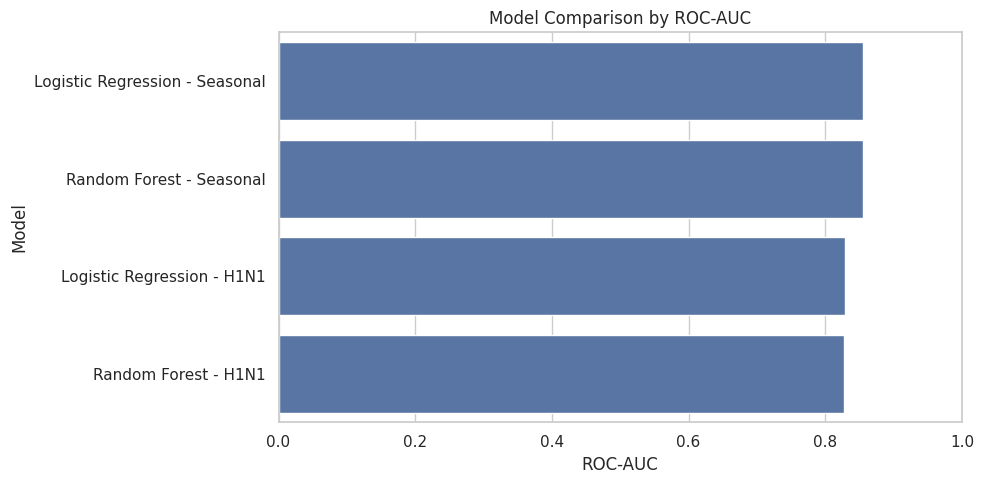

In [39]:
# Visual comparison of ROC-AUC
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="roc_auc", y="model")
plt.title("Model Comparison by ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [40]:
#  GET FEATURE NAMES AFTER PREPROCESSING


def get_feature_names_from_preprocessor(preprocessor):
    numeric_names = numeric_features

    categorical_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    categorical_names = categorical_encoder.get_feature_names_out(categorical_features)

    all_feature_names = list(numeric_names) + list(categorical_names)

    return all_feature_names

In [41]:
# Fit preprocessor inside the Random Forest pipeline has already happened.
# Now get feature names.
feature_names = get_feature_names_from_preprocessor(
    rf_h1n1.named_steps["preprocessor"])

print("Number of transformed features:", len(feature_names))
print(feature_names[:20])

Number of transformed features: 105
['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk']


In [42]:

# RANDOM FOREST FEATURE IMPORTANCE FOR H1N1

rf_h1n1_model = rf_h1n1.named_steps["model"]

h1n1_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_h1n1_model.feature_importances_
}).sort_values(by="importance", ascending=False)

h1n1_importance.head(20)

,feature,importance
9,doctor_recc_h1n1,0.094743
16,opinion_h1n1_risk,0.071996
15,opinion_h1n1_vacc_effective,0.067643
19,opinion_seas_risk,0.046967
18,opinion_seas_vacc_effective,0.030530
0,h1n1_concern,0.026436
17,opinion_h1n1_sick_from_vacc,0.026201
10,doctor_recc_seasonal,0.025009
20,opinion_seas_sick_from_vacc,0.024440
21,household_adults,0.020244


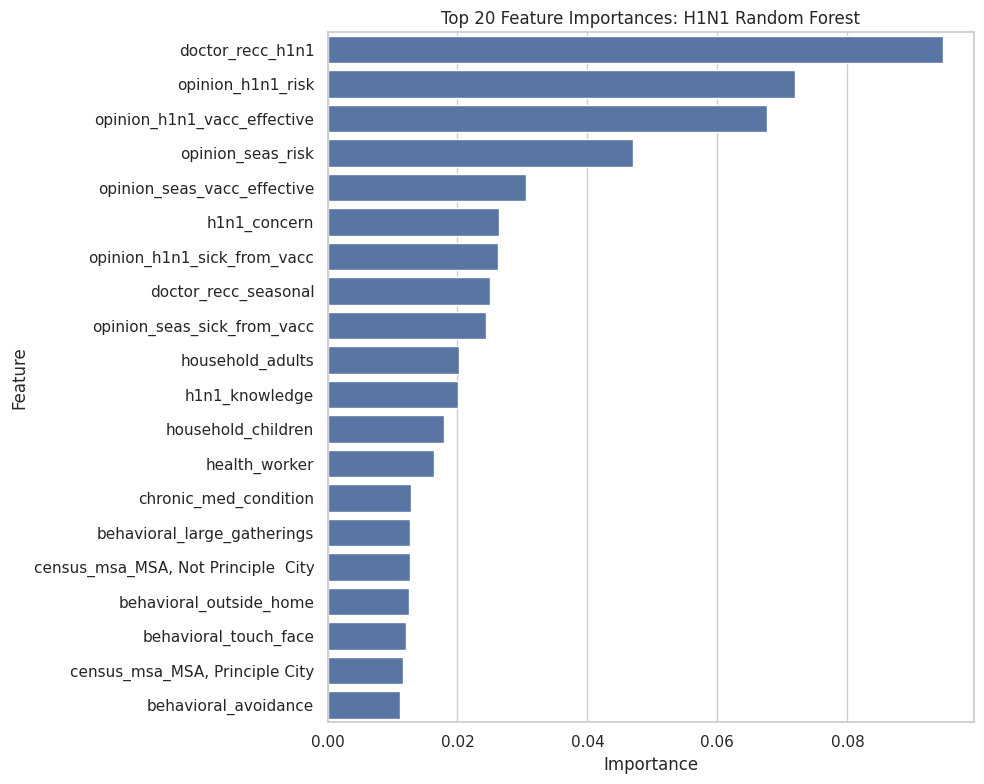

In [43]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=h1n1_importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importances: H1N1 Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [44]:

# RANDOM FOREST FEATURE IMPORTANCE FOR SEASONAL


feature_names_seasonal = get_feature_names_from_preprocessor(
    rf_seasonal.named_steps["preprocessor"])

rf_seasonal_model = rf_seasonal.named_steps["model"]

seasonal_importance = pd.DataFrame({
    "feature": feature_names_seasonal,
    "importance": rf_seasonal_model.feature_importances_
}).sort_values(by="importance", ascending=False)

seasonal_importance.head(20)

,feature,importance
19,opinion_seas_risk,0.087280
18,opinion_seas_vacc_effective,0.083591
10,doctor_recc_seasonal,0.063433
16,opinion_h1n1_risk,0.032868
15,opinion_h1n1_vacc_effective,0.031425
27,age_group_65+ Years,0.027059
20,opinion_seas_sick_from_vacc,0.026595
0,h1n1_concern,0.026117
17,opinion_h1n1_sick_from_vacc,0.025113
1,h1n1_knowledge,0.021336


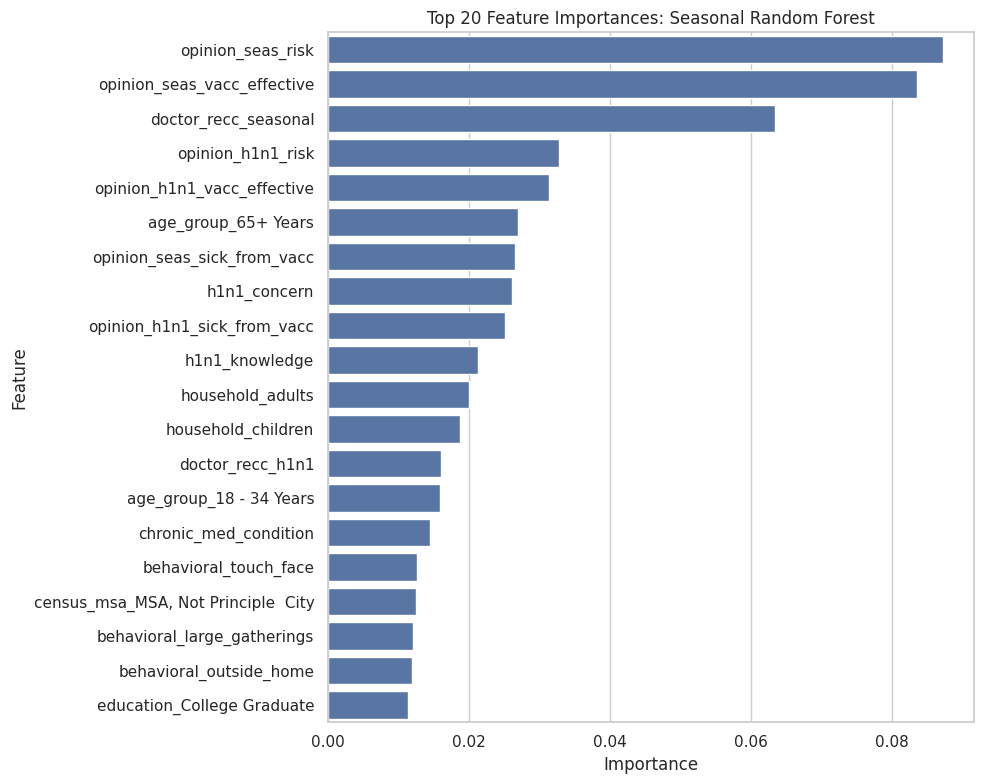

In [45]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=seasonal_importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importances: Seasonal Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [46]:
# TRAIN FINAL BASELINE MODELS ON FULL TRAINING DATA


final_h1n1_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")) ])

final_seasonal_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")) ])

final_h1n1_model.fit(X, y_h1n1)
final_seasonal_model.fit(X, y_seasonal)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_touch_face',
                                                   'doct...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'hhs_geo_region',
                                                   'census_msa',
                                                   'employment_industry',
                                                   'employment_occupation'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [47]:
# Prepare test features
X_test = test_features.drop(columns=["respondent_id"])

# Predict probabilities
test_h1n1_proba = final_h1n1_model.predict_proba(X_test)[:, 1]
test_seasonal_proba = final_seasonal_model.predict_proba(X_test)[:, 1]

print(test_h1n1_proba[:10])
print(test_seasonal_proba[:10])

[0.17737839 0.15899943 0.71105145 0.77502415 0.46637256 0.75859879
 0.66971618 0.36632717 0.13162584 0.49757613]
[0.31866154 0.05151979 0.61863698 0.89508237 0.50378612 0.9320575
 0.61520148 0.24583914 0.17202472 0.90099468]


In [48]:
# CREATE SUBMISSION FILE


submission = pd.DataFrame({
    "respondent_id": test_features["respondent_id"],
    "h1n1_vaccine": test_h1n1_proba,
    "seasonal_vaccine": test_seasonal_proba})

submission.head()

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,26707,0.177378,0.318662
1,26708,0.158999,0.051520
2,26709,0.711051,0.618637
3,26710,0.775024,0.895082
4,26711,0.466373,0.503786


In [49]:
# Save submission file
submission.to_csv("baseline_submission.csv", index=False)

print("Submission file saved as baseline_submission.csv")

Submission file saved as baseline_submission.csv
